<a href="https://www.kaggle.com/code/sonawanelalitsunil/paris-2024-olympic-track-field-results-ml-75?scriptVersionId=235552519" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/paris-2024-olympic-games-track-and-field-results/results.csv
/kaggle/input/paris-2024-olympic-games-track-and-field-results/events.csv


In [2]:
df = pd.read_csv('/kaggle/input/paris-2024-olympic-games-track-and-field-results/results.csv')

In [3]:
df.head()

,local_time,sex,event,round,startlist_url,results_url,summary_url,points_url,pos,bib,name,country,mark
0,08:00,M,20 Kilometres Race Walk,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,1.0,29.0,Brian Daniel PINTADO,ECU,1:18:55
1,08:00,M,20 Kilometres Race Walk,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,2.0,15.0,Caio BONFIM,BRA,1:19:09
2,08:00,M,20 Kilometres Race Walk,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,3.0,33.0,Álvaro MARTÍN,ESP,1:19:11
3,08:00,M,20 Kilometres Race Walk,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,4.0,55.0,Massimo STANO,ITA,1:19:12
4,08:00,M,20 Kilometres Race Walk,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,5.0,18.0,Evan DUNFEE,CAN,1:19:16


In [4]:
df.tail()

,local_time,sex,event,round,startlist_url,results_url,summary_url,points_url,pos,bib,name,country,mark
3545,08:00,W,Marathon,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,NaN,1917.0,Melat Yisak KEJETA,GER,DNF
3546,08:00,W,Marathon,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,NaN,2374.0,Jackline SAKILU,TAN,DNF
3547,08:00,W,Marathon,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,NaN,2297.0,Joan Chelimo MELLY,ROU,DNF
3548,08:00,W,Marathon,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,NaN,1522.0,Sinead DIVER,AUS,DNF
3549,08:00,W,Marathon,Final,https://worldathletics.org/results/olympic-gam...,https://worldathletics.org/results/olympic-gam...,NaN,NaN,NaN,2461.0,Fiona O'KEEFFE,USA,DNF


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   local_time     3550 non-null   object 
 1   sex            3550 non-null   object 
 2   event          3550 non-null   object 
 3   round          3550 non-null   object 
 4   startlist_url  3550 non-null   object 
 5   results_url    3550 non-null   object 
 6   summary_url    2777 non-null   object 
 7   points_url     435 non-null    object 
 8   pos            3401 non-null   float64
 9   bib            3404 non-null   float64
 10  name           3550 non-null   object 
 11  country        3550 non-null   object 
 12  mark           3550 non-null   object 
dtypes: float64(2), object(11)
memory usage: 360.7+ KB


In [6]:
df.describe()

,pos,bib
count,3401.000000,3404.000000
mean,7.974713,1339.665981
std,9.535288,695.842457
min,1.000000,10.000000
25%,3.000000,741.500000
50%,6.000000,1292.500000
75%,9.000000,1960.000000
max,80.000000,2496.000000


In [7]:
df.isnull().sum()

local_time          0
sex                 0
event               0
round               0
startlist_url       0
results_url         0
summary_url       773
points_url       3115
pos               149
bib               146
name                0
country             0
mark                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3550, 13)

In [10]:
df.columns

Index(['local_time', 'sex', 'event', 'round', 'startlist_url', 'results_url',
       'summary_url', 'points_url', 'pos', 'bib', 'name', 'country', 'mark'],
      dtype='object')

## Data visualizations

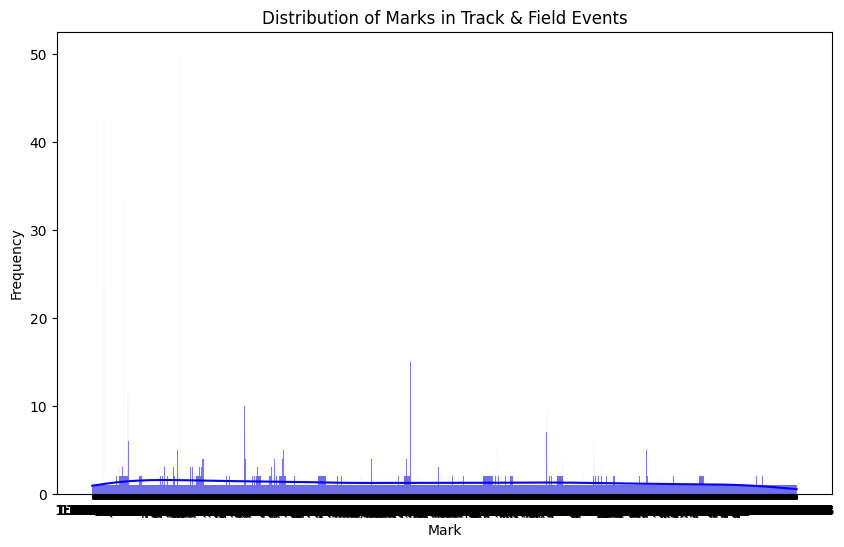

In [11]:
# 1. Distribution of Marks (Performance)
plt.figure(figsize=(10, 6))
sns.histplot(df['mark'], bins=30, kde=True, color='blue')
plt.title('Distribution of Marks in Track & Field Events')
plt.xlabel('Mark')
plt.ylabel('Frequency')
plt.show()

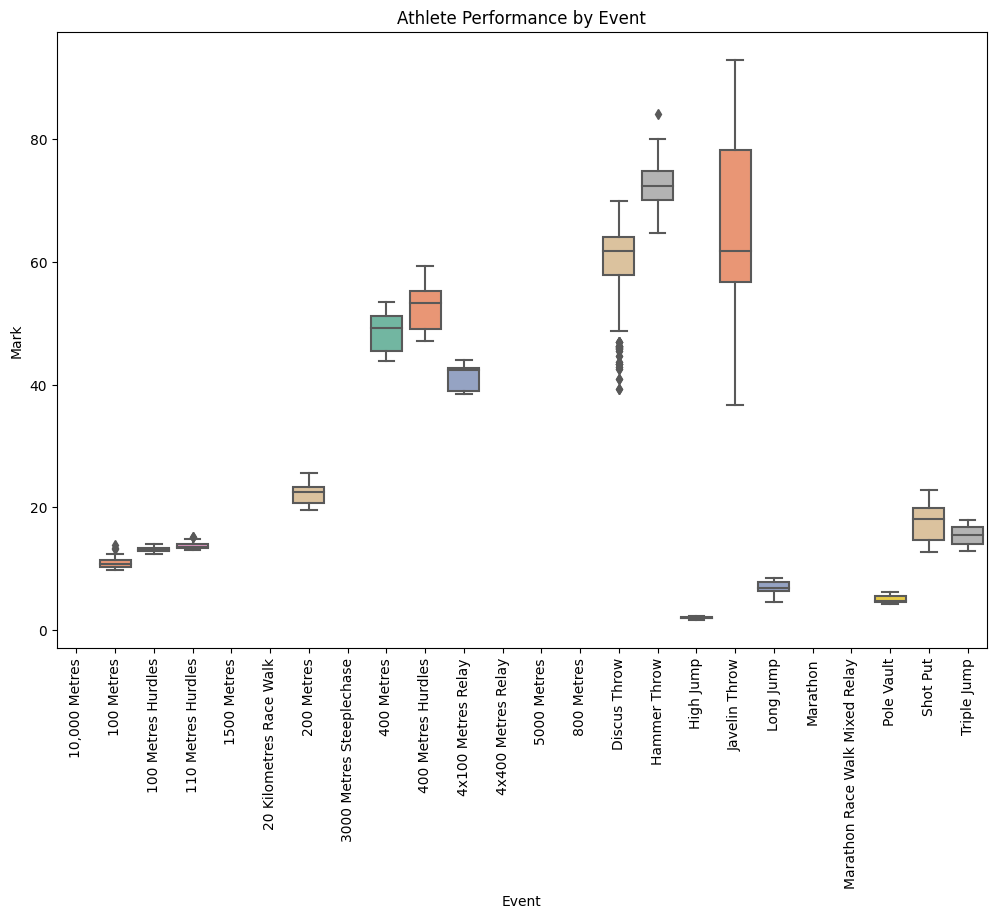

In [12]:
# Convert 'mark' to numeric, forcing errors to NaN
df['mark'] = pd.to_numeric(df['mark'], errors='coerce')

# Convert 'event' to categorical if it's not already
df['event'] = df['event'].astype('category')

# 2. Athlete Performance by Event (Boxplot)
plt.figure(figsize=(12, 8))
sns.boxplot(x='event', y='mark', data=df, palette="Set2")
plt.title('Athlete Performance by Event')
plt.xlabel('Event')
plt.ylabel('Mark')
plt.xticks(rotation=90)
plt.show()


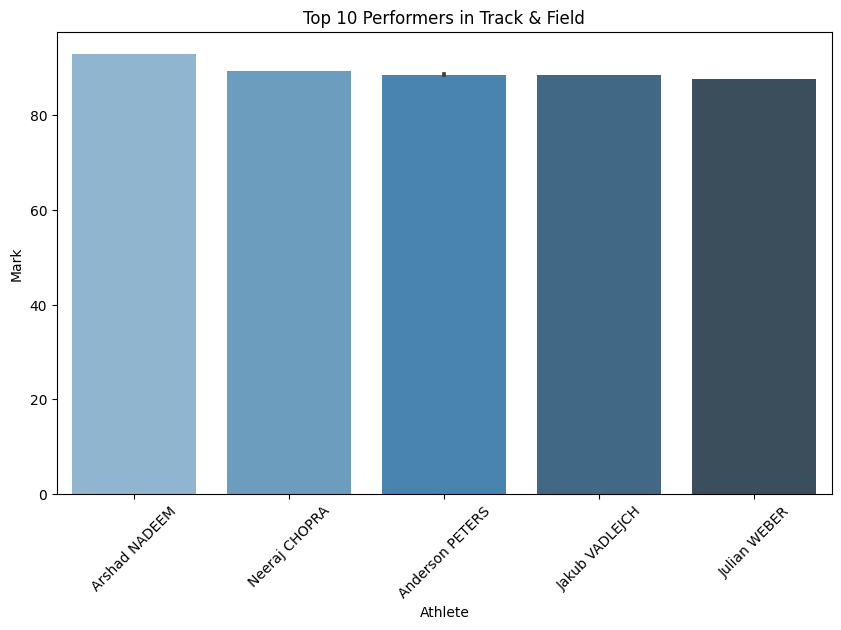

In [13]:
# 3. Top 10 Performers (Based on Marks)
top_performers = df.nlargest(10, 'mark')
plt.figure(figsize=(10, 6))
sns.barplot(x='name', y='mark', data=top_performers, palette="Blues_d")
plt.title('Top 10 Performers in Track & Field')
plt.xlabel('Athlete')
plt.ylabel('Mark')
plt.xticks(rotation=45)
plt.show()

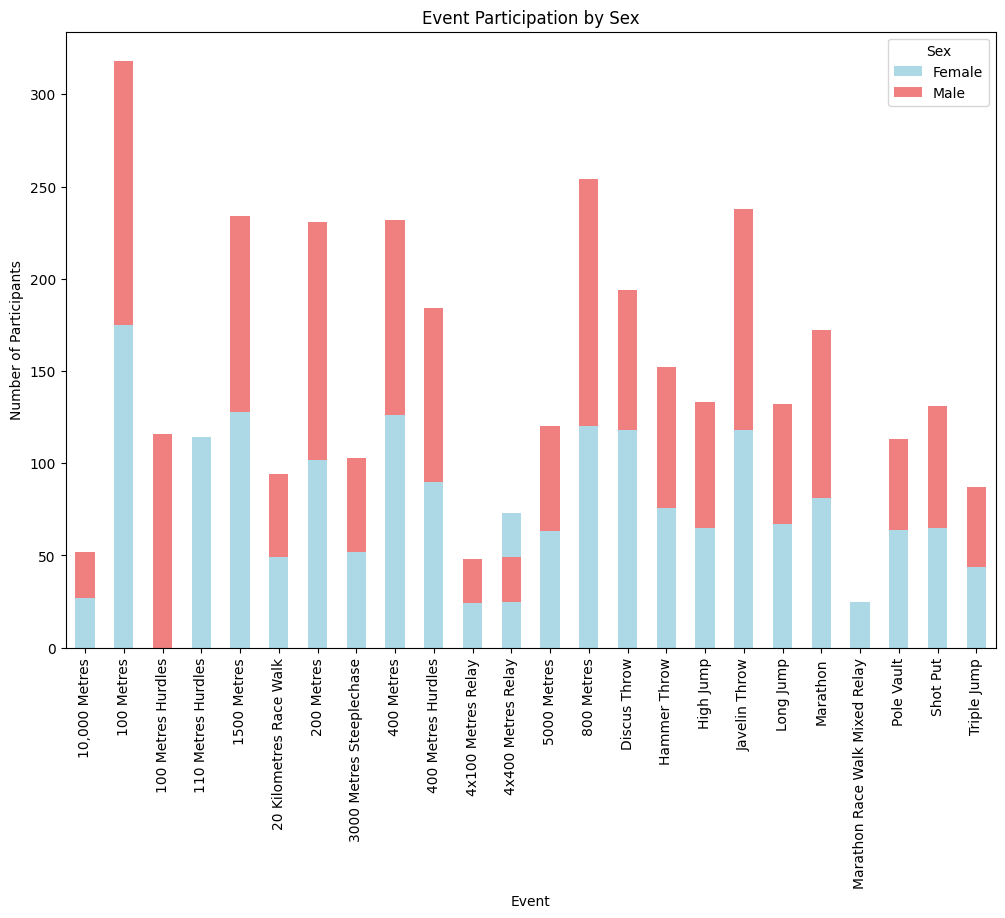

In [14]:
# 4. Event Participation by Sex (Gender Breakdown)
event_sex_count = df.groupby(['event', 'sex']).size().unstack().fillna(0)
event_sex_count.plot(kind='bar', stacked=True, figsize=(12, 8), color=['lightblue', 'lightcoral'])
plt.title('Event Participation by Sex')
plt.xlabel('Event')
plt.ylabel('Number of Participants')
plt.xticks(rotation=90)
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.show()

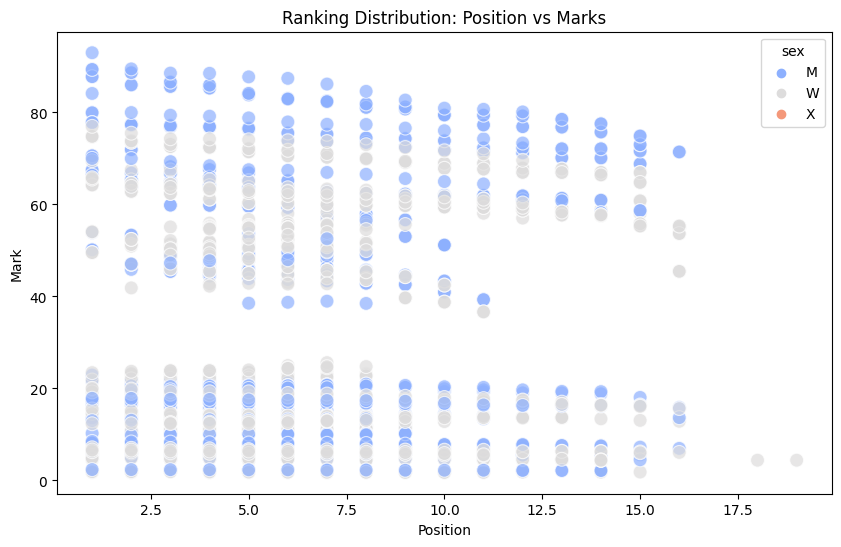

In [15]:
# 5. Ranking Distribution (Position vs Marks)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pos', y='mark', data=df, hue='sex', palette='coolwarm', s=100, alpha=0.7)
plt.title('Ranking Distribution: Position vs Marks')
plt.xlabel('Position')
plt.ylabel('Mark')
plt.show()

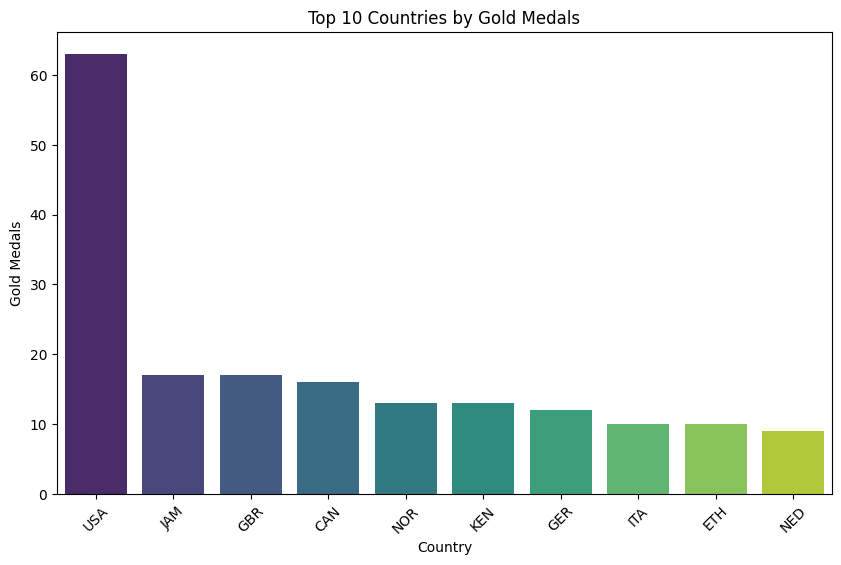

In [16]:
# 6. Medal Distribution by Country
country_medals = df.groupby('country')['pos'].value_counts().unstack().fillna(0)
country_medals = country_medals[1]  # Focus on first position (Gold Medalists)
country_medals = country_medals.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=country_medals.index, y=country_medals.values, palette='viridis')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Country')
plt.ylabel('Gold Medals')
plt.xticks(rotation=45)
plt.show()

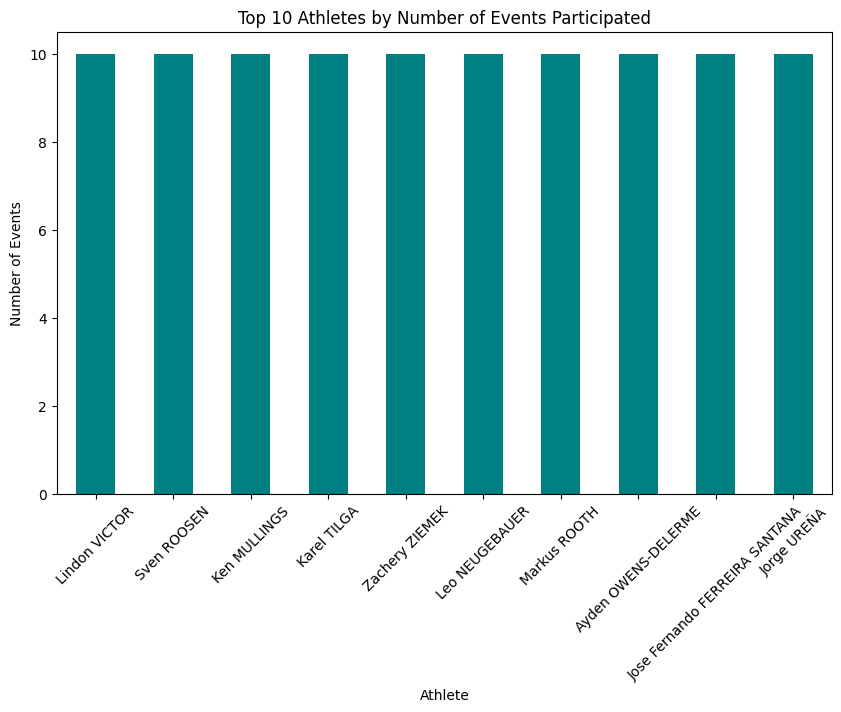

In [17]:
# 7. Number of Events per Athlete
athlete_events = df.groupby('name')['event'].nunique().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
athlete_events.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Athletes by Number of Events Participated')
plt.xlabel('Athlete')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

## Predictive modeling

In [18]:
# Now proceed with your existing code to create the 'podium' column
df['podium'] = df['pos'] <= 3

print('Podium finish counts:')
print(df['podium'].value_counts())

# Select features for our model
feature_columns = ['bib', 'sex', 'event', 'round', 'country']
model_df = df[feature_columns + ['podium']].dropna()

# One-hot encoding for categorical variables
model_df_encoded = pd.get_dummies(model_df, columns=['sex', 'event', 'round', 'country'], drop_first=True)

# Check the shape of the encoded data
print('Shape of data after encoding:', model_df_encoded.shape)

# Display the first few rows of the encoded data
model_df_encoded.head()

Podium finish counts:
podium
False    2577
True      973
Name: count, dtype: int64
Shape of data after encoding: (3404, 237)


,bib,podium,sex_W,event_100 Metres,event_100 Metres Hurdles,event_110 Metres Hurdles,event_1500 Metres,event_20 Kilometres Race Walk,event_200 Metres,event_3000 Metres Steeplechase,...,country_URU,country_USA,country_UZB,country_VAN,country_VEN,country_VIE,country_VIN,country_YEM,country_ZAM,country_ZIM
0,29.0,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,15.0,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,33.0,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,55.0,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,18.0,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
# Proceed with splitting the dataset and applying models as before
X = model_df_encoded.drop('podium', axis=1)
y = model_df_encoded['podium']

In [20]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [21]:
# Define and train your models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt


Training and evaluating Logistic Regression...
Accuracy of Logistic Regression: 0.7446183953033269

Classification Report for Logistic Regression
              precision    recall  f1-score   support

       False       0.76      0.96      0.85       744
        True       0.60      0.18      0.27       278

    accuracy                           0.74      1022
   macro avg       0.68      0.57      0.56      1022
weighted avg       0.72      0.74      0.69      1022



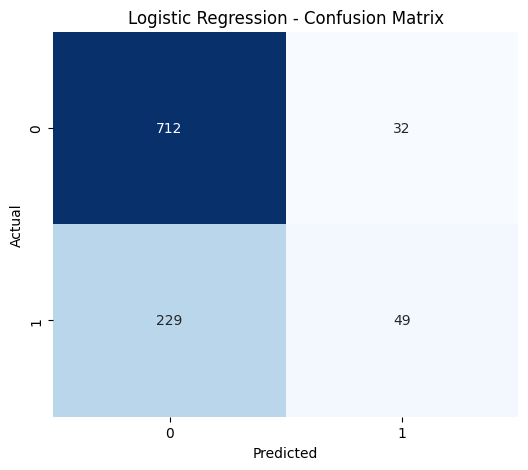

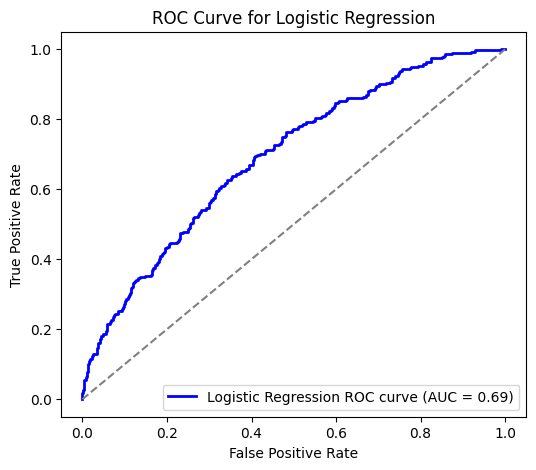


Training and evaluating Random Forest...
Accuracy of Random Forest: 0.6956947162426614

Classification Report for Random Forest
              precision    recall  f1-score   support

       False       0.76      0.86      0.80       744
        True       0.41      0.27      0.32       278

    accuracy                           0.70      1022
   macro avg       0.58      0.56      0.56      1022
weighted avg       0.66      0.70      0.67      1022



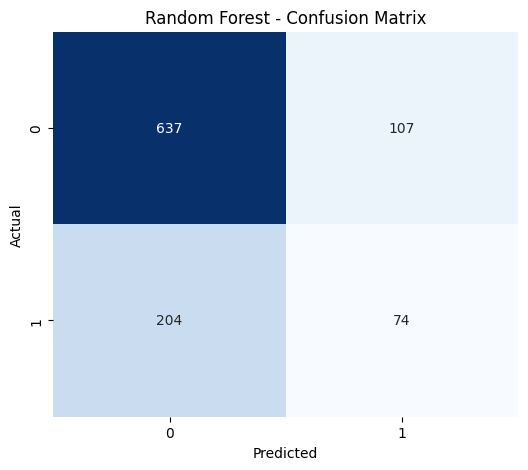

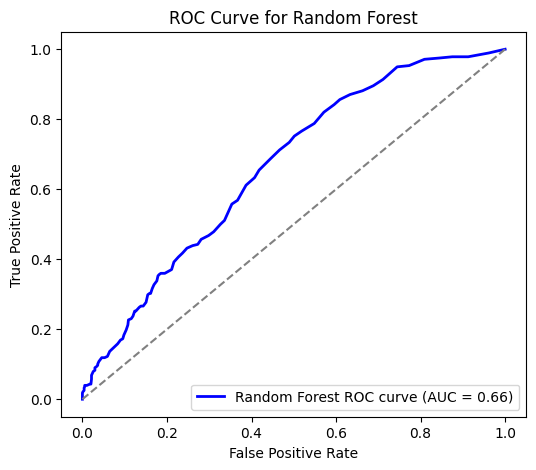


Training and evaluating Support Vector Machine...
Accuracy of Support Vector Machine: 0.7279843444227005

Classification Report for Support Vector Machine
              precision    recall  f1-score   support

       False       0.73      1.00      0.84       744
        True       0.00      0.00      0.00       278

    accuracy                           0.73      1022
   macro avg       0.36      0.50      0.42      1022
weighted avg       0.53      0.73      0.61      1022



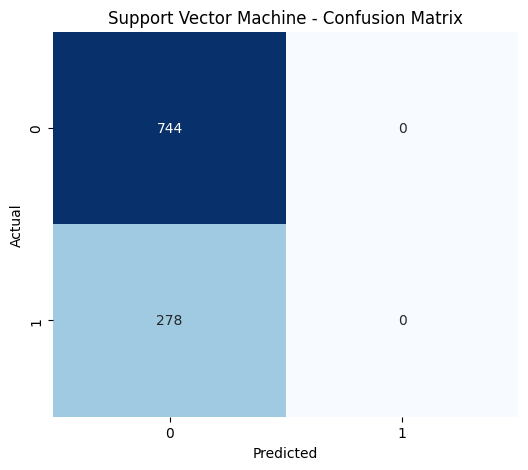

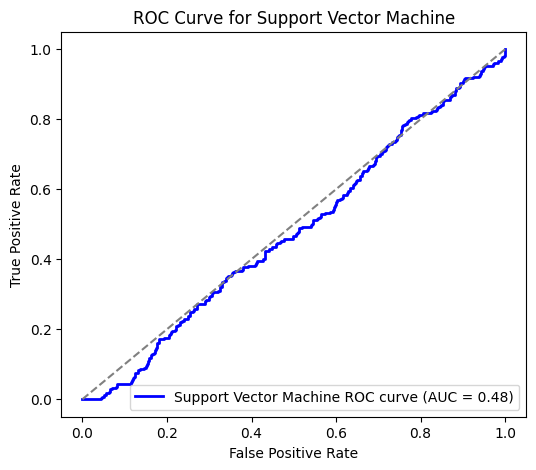


Training and evaluating K-Nearest Neighbors...
Accuracy of K-Nearest Neighbors: 0.7181996086105675

Classification Report for K-Nearest Neighbors
              precision    recall  f1-score   support

       False       0.77      0.87      0.82       744
        True       0.47      0.31      0.38       278

    accuracy                           0.72      1022
   macro avg       0.62      0.59      0.60      1022
weighted avg       0.69      0.72      0.70      1022



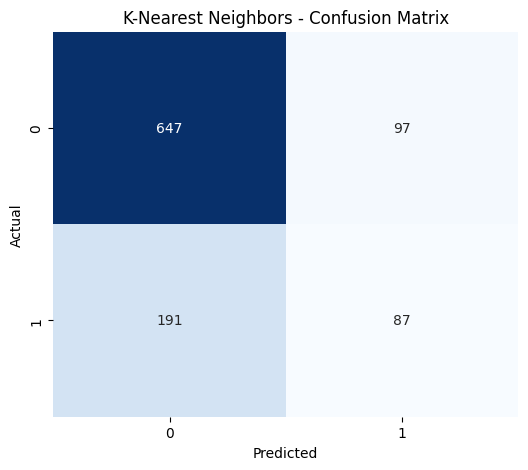

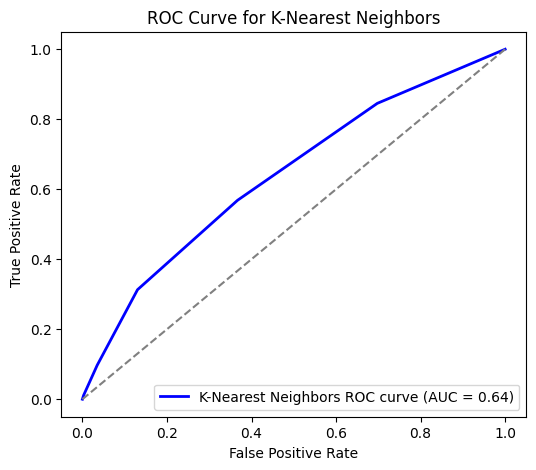


Training and evaluating Gradient Boosting...
Accuracy of Gradient Boosting: 0.7465753424657534

Classification Report for Gradient Boosting
              precision    recall  f1-score   support

       False       0.75      0.98      0.85       744
        True       0.69      0.13      0.21       278

    accuracy                           0.75      1022
   macro avg       0.72      0.55      0.53      1022
weighted avg       0.73      0.75      0.68      1022



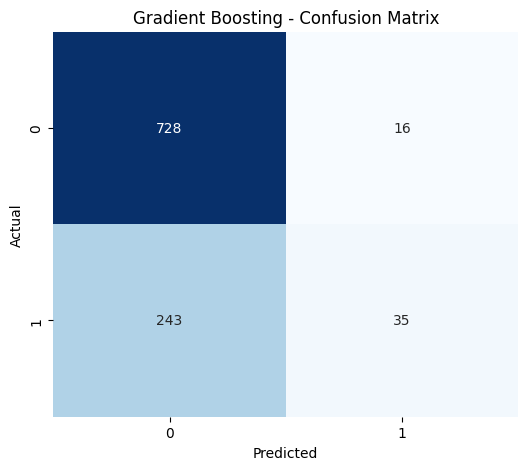

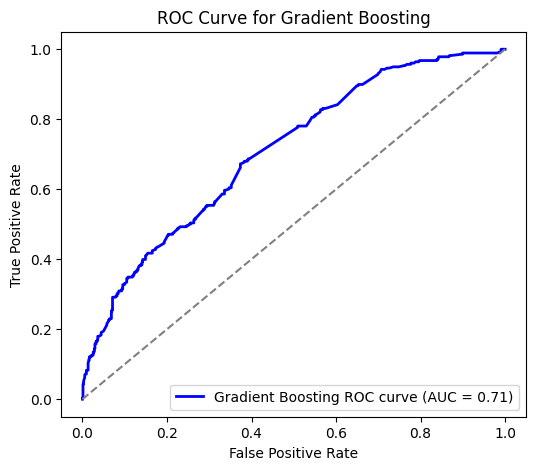


Training and evaluating Naive Bayes...
Accuracy of Naive Bayes: 0.41682974559686886

Classification Report for Naive Bayes
              precision    recall  f1-score   support

       False       0.85      0.24      0.38       744
        True       0.30      0.88      0.45       278

    accuracy                           0.42      1022
   macro avg       0.58      0.56      0.41      1022
weighted avg       0.70      0.42      0.40      1022



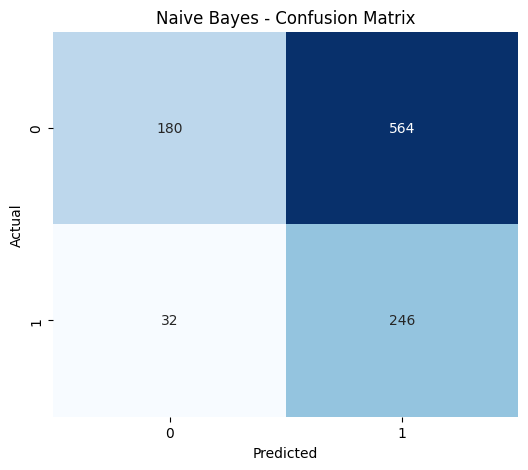

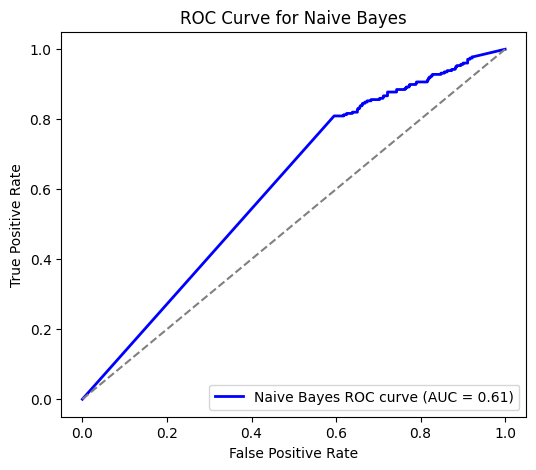


Training and evaluating Decision Tree...
Accuracy of Decision Tree: 0.6937377690802349

Classification Report for Decision Tree
              precision    recall  f1-score   support

       False       0.78      0.81      0.79       744
        True       0.43      0.39      0.41       278

    accuracy                           0.69      1022
   macro avg       0.61      0.60      0.60      1022
weighted avg       0.69      0.69      0.69      1022



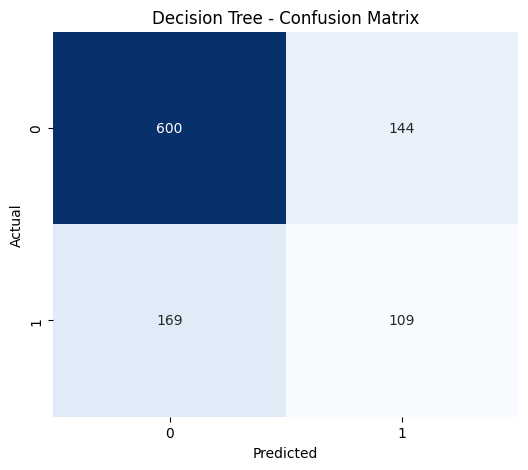

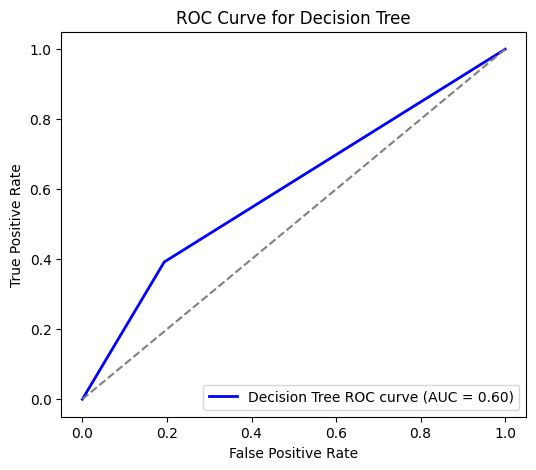

In [22]:
# Model dictionary
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Loop through models, train, and evaluate them
for model_name, model in models.items():
    print(f'\nTraining and evaluating {model_name}...')
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy score
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy of {model_name}: {acc}')
    
    # Classification report
    print("\nClassification Report for", model_name)
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'{model_name} ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

## Thank you..pls upvote!!!!!